# Notebook 01 - Data exploration and preprocessing

In this notebook we look at our dataset before training any model. We check how many images we have per class, we look at some sample images, we look at the pixel histograms, and we try some preprocessing techniques from the CV sessions (CLAHE, blur, Canny, thresholding). At the end we also show how the augmentation will look for training.

### Importing the libraries

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

os.makedirs("../docs/figures", exist_ok=True)

### Downloading the dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruit-and-vegetable-disease-healthy-vs-rotten' dataset.
Path to dataset files: /kaggle/input/fruit-and-vegetable-disease-healthy-vs-rotten


### Checking the folders

The dataset is organized in folders, one folder per class, inside a Train and a Test folder. Let's look at the folder names.

In [5]:
train_dir = os.path.join(path, "Fruit And Vegetable Diseases Dataset")

print(os.listdir(train_dir))

['Strawberry__Rotten', 'Grape__Rotten', 'Guava__Healthy', 'Orange__Rotten', 'Tomato__Healthy', 'Pomegranate__Healthy', 'Potato__Healthy', 'Jujube__Rotten', 'Apple__Healthy', 'Banana__Healthy', 'Potato__Rotten', 'Mango__Healthy', 'Banana__Rotten', 'Bellpepper__Healthy', 'Carrot__Healthy', 'Strawberry__Healthy', 'Bellpepper__Rotten', 'Guava__Rotten', 'Orange__Healthy', 'Mango__Rotten', 'Cucumber__Rotten', 'Cucumber__Healthy', 'Jujube__Healthy', 'Carrot__Rotten', 'Pomegranate__Rotten', 'Tomato__Rotten', 'Apple__Rotten', 'Grape__Healthy']


### Counting images per class (all classes)

The raw dataset has many fruits and vegetables, not just the ones we use in FreshGuard. Before filtering, we count how many images each class has, so we understand the full dataset.

In [6]:
all_classes = sorted(os.listdir(train_dir))
all_counts = []

for class_name in all_classes:
    class_path = os.path.join(train_dir, class_name)
    n_images = len(os.listdir(class_path))
    all_counts.append(n_images)
    print(class_name, "->", n_images, "images")

Apple__Healthy -> 2438 images
Apple__Rotten -> 2930 images
Banana__Healthy -> 2000 images
Banana__Rotten -> 2800 images
Bellpepper__Healthy -> 611 images
Bellpepper__Rotten -> 591 images
Carrot__Healthy -> 620 images
Carrot__Rotten -> 580 images
Cucumber__Healthy -> 608 images
Cucumber__Rotten -> 593 images
Grape__Healthy -> 200 images
Grape__Rotten -> 200 images
Guava__Healthy -> 200 images
Guava__Rotten -> 200 images
Jujube__Healthy -> 200 images
Jujube__Rotten -> 200 images
Mango__Healthy -> 1813 images
Mango__Rotten -> 2247 images
Orange__Healthy -> 2075 images
Orange__Rotten -> 2186 images
Pomegranate__Healthy -> 200 images
Pomegranate__Rotten -> 200 images
Potato__Healthy -> 615 images
Potato__Rotten -> 585 images
Strawberry__Healthy -> 1603 images
Strawberry__Rotten -> 1596 images
Tomato__Healthy -> 604 images
Tomato__Rotten -> 596 images


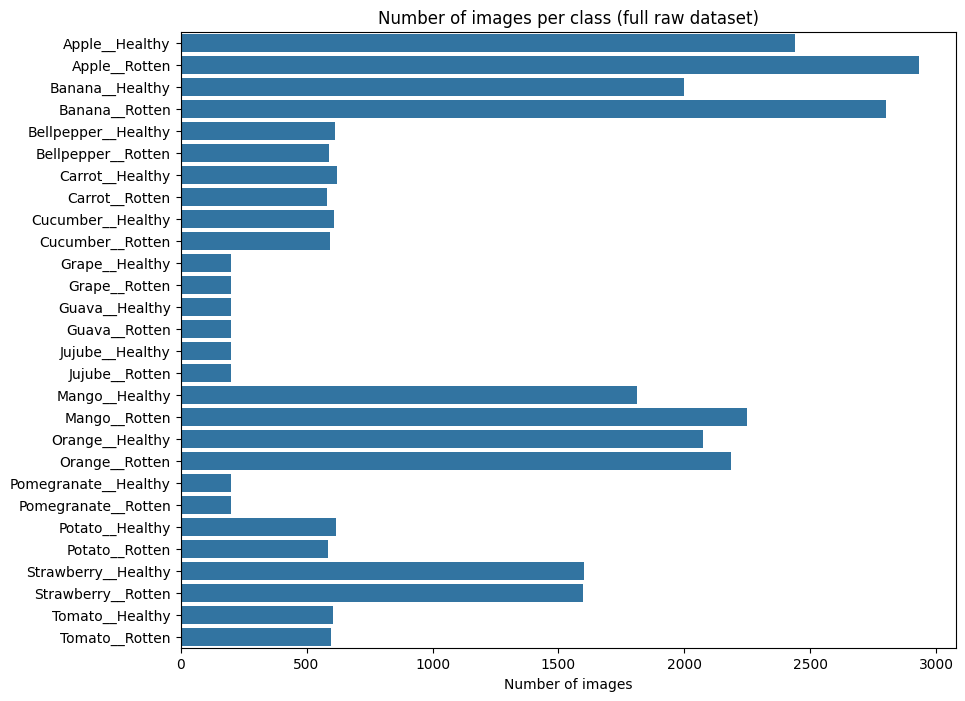

In [9]:
plt.figure(figsize=(10, 8))
sns.barplot(x=all_counts, y=all_classes)
plt.title("Number of images per class (full raw dataset)")
plt.xlabel("Number of images")
plt.savefig("../docs/figures/01_raw_class_distribution.png", bbox_inches="tight")
plt.show()

### Selecting the classes we use

FreshGuard grades **10 produce types** (each as healthy/rotten = **20 classes**):
apple, banana, orange, carrot, tomato, potato, cucumber, bell pepper, mango, strawberry.
In the trained model the folder label `Healthy` becomes `fresh_*` and `Rotten` becomes `rotten_*`.

We do **not** use all 14 types in the raw dataset. Four of them — grape, guava, jujube and
pomegranate — only have ~200 images each (you can see this in the chart above), too few to learn
reliably, so we drop them and keep the 10 types that have enough data. Of those 10,
apple/banana/orange/carrot are also recognised in real time by the object detector (YOLO / COCO);
the other six are graded from a center crop of the frame.

If a folder name below doesn't match what was printed above, fix the name in the list.

In [ ]:
selected_classes = [
    "Apple__Healthy",      "Apple__Rotten",
    "Banana__Healthy",     "Banana__Rotten",
    "Orange__Healthy",     "Orange__Rotten",
    "Carrot__Healthy",     "Carrot__Rotten",
    "Tomato__Healthy",     "Tomato__Rotten",
    "Potato__Healthy",     "Potato__Rotten",
    "Cucumber__Healthy",   "Cucumber__Rotten",
    "Bellpepper__Healthy", "Bellpepper__Rotten",
    "Mango__Healthy",      "Mango__Rotten",
    "Strawberry__Healthy", "Strawberry__Rotten",
]

for c in selected_classes:
    if c not in all_classes:
        print("Not found, check the name:", c)

### Counting images per class (our 20 classes)

In [11]:
counts = []

for class_name in selected_classes:
    class_path = os.path.join(train_dir, class_name)
    n_images = len(os.listdir(class_path))
    counts.append(n_images)
    print(class_name, "->", n_images, "images")

Apple__Healthy -> 2438 images
Apple__Rotten -> 2930 images
Banana__Healthy -> 2000 images
Banana__Rotten -> 2800 images
Carrot__Healthy -> 620 images
Carrot__Rotten -> 580 images
Orange__Healthy -> 2075 images
Orange__Rotten -> 2186 images


In [ ]:
colors = []
for c in selected_classes:
    if "Healthy" in c:
        colors.append("green")
    else:
        colors.append("red")

plt.figure(figsize=(13, 5))
plt.bar(selected_classes, counts, color=colors)
plt.title("Number of images per class (our 20 classes)")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../docs/figures/02_class_distribution.png", bbox_inches="tight")
plt.show()

We can see if the classes are balanced or not. If some classes have a lot more images than others, this is something we need to keep in mind when training the model, because the model could end up biased towards the bigger classes.

### Looking at sample images

Let's load a few images from each class and display them, so we can see what the data actually looks like.

In [ ]:
cols = 4
rows = (len(selected_classes) + cols - 1) // cols   # 5 rows for 20 classes
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
axes = axes.flatten()

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(train_dir, class_name)
    file_name = os.listdir(class_path)[0]
    img = cv2.cvtColor(cv2.imread(os.path.join(class_path, file_name)), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    axes[i].imshow(img)
    axes[i].set_title(class_name.replace("__", " "), fontsize=9)
    axes[i].axis("off")

for j in range(len(selected_classes), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../docs/figures/03_sample_images.png", bbox_inches="tight")
plt.show()

### RGB histograms

Now we compare the color histograms of a healthy and a rotten image. If a fruit is rotten, the colors usually become darker and more brown, so we expect the histograms to look different.

In [14]:
def load_image(class_name, index=0):
    class_path = os.path.join(train_dir, class_name)
    file_name = os.listdir(class_path)[index]
    img_path = os.path.join(class_path, file_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    return img

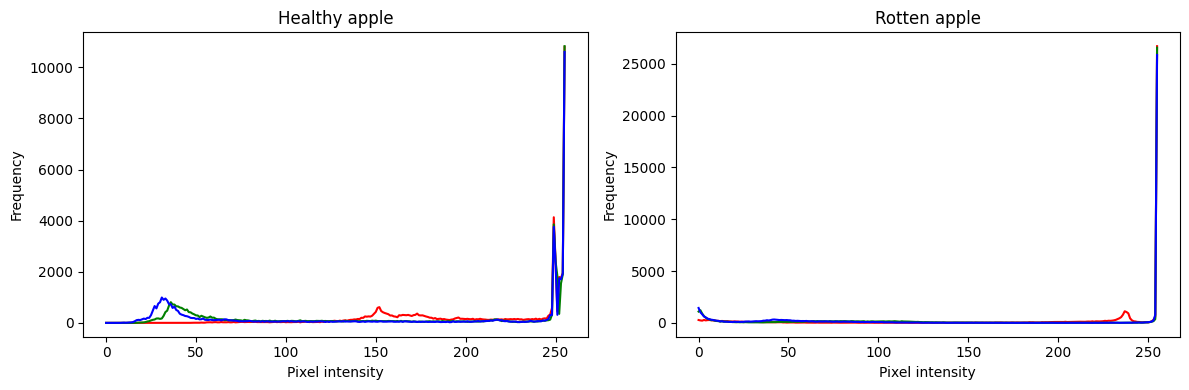

In [15]:
healthy_img = load_image("Apple__Healthy")
rotten_img = load_image("Apple__Rotten")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ("r", "g", "b")
for i, c in enumerate(colors):
    hist = cv2.calcHist([healthy_img], [i], None, [256], [0, 256])
    axes[0].plot(hist, color=c)
axes[0].set_title("Healthy apple")
axes[0].set_xlabel("Pixel intensity")
axes[0].set_ylabel("Frequency")

for i, c in enumerate(colors):
    hist = cv2.calcHist([rotten_img], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=c)
axes[1].set_title("Rotten apple")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../docs/figures/04_rgb_histograms.png", bbox_inches="tight")
plt.show()

### Preprocessing

Now we try the preprocessing techniques from the CV sessions. The idea is to check how each technique changes the image, and think about why it could help our model.

We use the following techniques:

- Histogram equalization: makes the contrast more even across the image. This can help because in the supermarket the lighting will not always be the same.
- CLAHE: similar to histogram equalization but works on small regions of the image, so it does not overdo it in bright or dark areas.
- Gaussian blur: removes small noise from the image.
- Canny edge detection: finds the edges in the image, which can help to find the borders of the rotten spots.
- Thresholding: separates dark areas from bright areas, which can help to isolate the rotten parts of the fruit.

In [16]:
img = load_image("Banana__Rotten")
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# histogram equalization
img_eq = cv2.equalizeHist(gray)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(gray)

# Gaussian blur
img_blur = cv2.GaussianBlur(img, (7, 7), 0)

# Canny edges
img_canny = cv2.Canny(gray, 50, 150)

# thresholding
_, img_thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

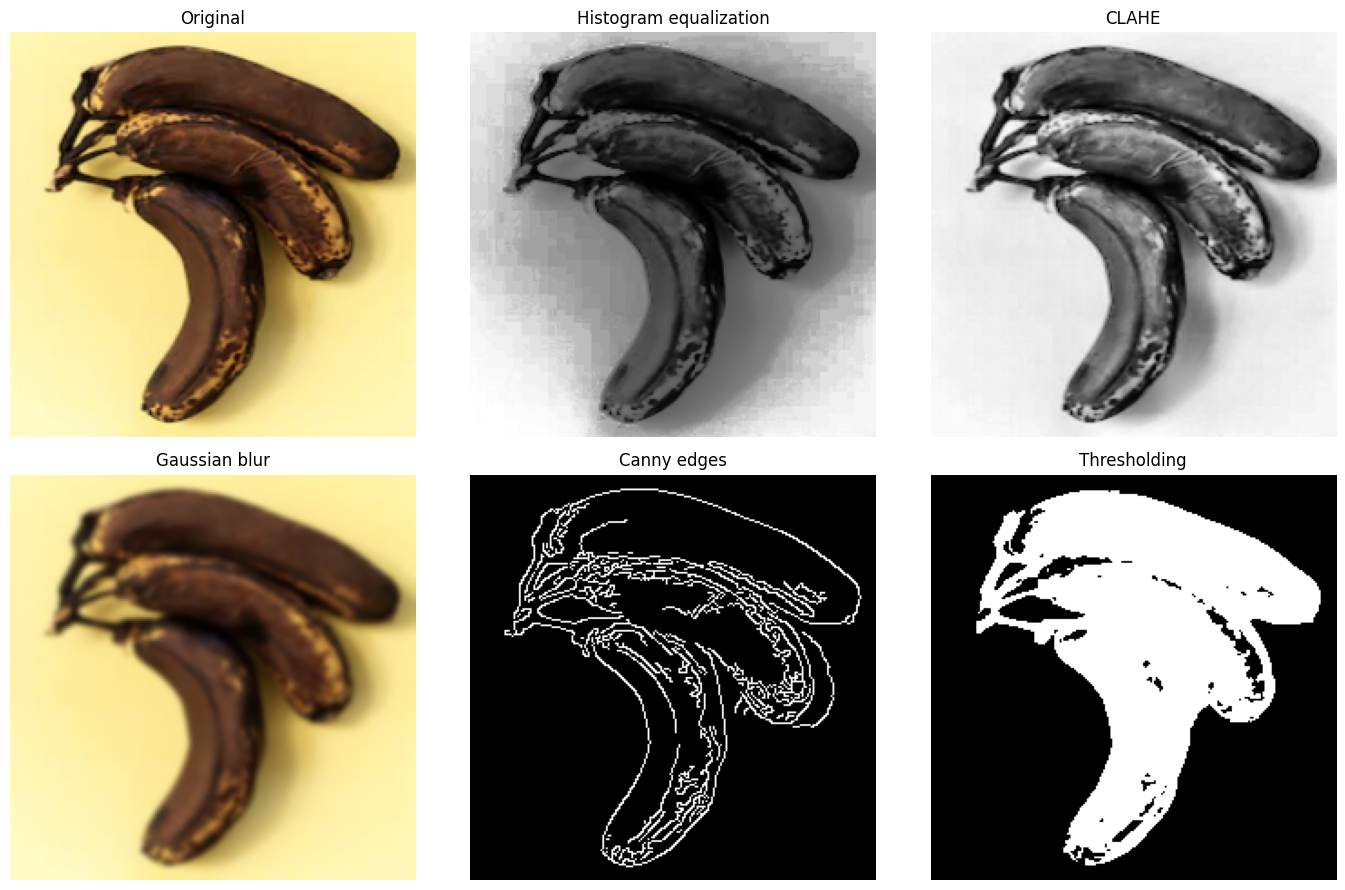

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(img)
axes[0, 0].set_title("Original")

axes[0, 1].imshow(img_eq, cmap="gray")
axes[0, 1].set_title("Histogram equalization")

axes[0, 2].imshow(img_clahe, cmap="gray")
axes[0, 2].set_title("CLAHE")

axes[1, 0].imshow(img_blur)
axes[1, 0].set_title("Gaussian blur")

axes[1, 1].imshow(img_canny, cmap="gray")
axes[1, 1].set_title("Canny edges")

axes[1, 2].imshow(img_thresh, cmap="gray")
axes[1, 2].set_title("Thresholding")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../docs/figures/05_preprocessing.png", bbox_inches="tight")
plt.show()

We can see that the Canny edges and the thresholding both pick up the rotten spot on the banana. This makes sense because the rotten spot is much darker than the rest of the fruit, so it stands out in both techniques.

### Data augmentation

When we train the model, we will use data augmentation to make the model more robust. This means we apply small random changes to the images during training, so the model sees more variety and does not just memorize the exact training images.

Here is why each augmentation makes sense for our case:

- Rotation: in the store, the fruit will not always be facing the camera in the same way.
- Horizontal flip: a fruit looks the same if we flip the image, so this gives us a free extra example.
- Zoom: the camera could be closer or further away from the fruit.
- Brightness change: the lighting in the store can be different from the lighting in the dataset photos.

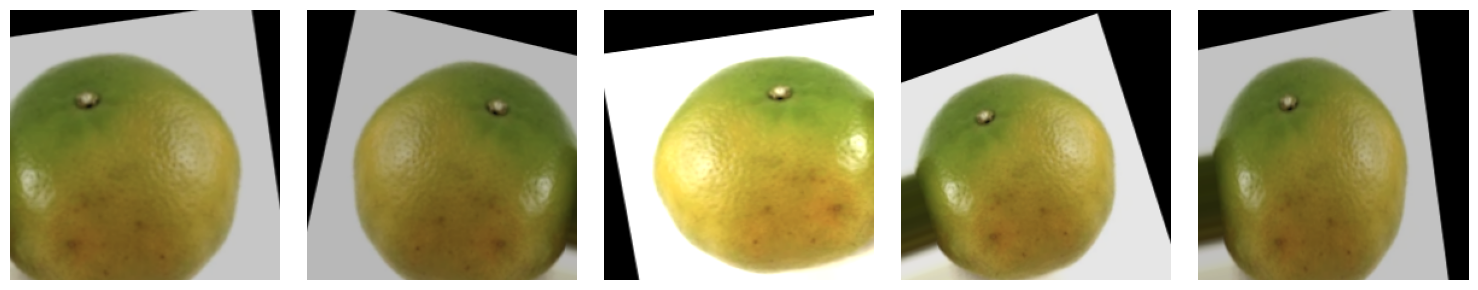

In [18]:
datagen = ImageDataGenerator(
    rotation_range=25,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
)

sample = load_image("Orange__Healthy")
sample = sample.reshape((1,) + sample.shape)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

i = 0
for batch in datagen.flow(sample, batch_size=1):
    axes[i].imshow(batch[0].astype("uint8"))
    axes[i].axis("off")
    i += 1
    if i == 5:
        break

plt.tight_layout()
plt.savefig("../docs/figures/06_augmentation.png", bbox_inches="tight")
plt.show()

### Summary

In this notebook we explored the dataset, checked the class distribution, looked at sample images and histograms, tried some preprocessing techniques, and previewed the data augmentation we will use for training. All the figures were saved in docs/figures so we can use them in the presentation.